# Fruit Classification CNN

In [44]:
import torch
import numpy as np

# check if CUDA is available
train_on_gpu = torch.cuda.is_available()

if not train_on_gpu:
    print('CUDA is not available.  Training on CPU ...')
else:
    print('CUDA is available!  Training on GPU ...')

CUDA is available!  Training on GPU ...


## Organizing the test data to match the train and validation data
The folders were not in the correct order but they are listed in order from top to bottom in the csv files

In [45]:
# Organizing the classes correctly
import pandas as pd
folder_to_class = {}
test_df = pd.read_csv('Fruit_dataset/test.csv')
val_df = pd.read_csv('Fruit_dataset/val.csv')

val_classes = ['']
test_classes = ['']

for i in range(len(test_df)):
    folder_loc = test_df.iloc[i]['image:FILE'].split('/')[1]
    if not folder_loc: break
    if folder_loc != test_classes[-1]:
        test_classes.append(folder_loc)
        
for i in range(len(val_df)):
    folder_loc = val_df.iloc[i]['image:FILE'].split('/')[1]
    if folder_loc != val_classes[-1]:
        val_classes.append(folder_loc)

val_classes = val_classes[1:]
test_classes = test_classes[1:]
folder_to_class = dict(zip(val_classes, test_classes))

print(folder_to_class)


{'oil_palm': '28', 'hog_plum': '3', 'apricot': '93', 'sugar_apple': '58', 'rambutan': '80', 'yellow_plum': '49', 'pineapple': '43', 'dewberry': '71', 'plumcot': '23', 'ambarella': '8', 'grenadilla': '46', 'elderberry': '98', 'barbadine': '87', 'horned_melon': '39', 'chico': '61', 'mock_strawberry': '92', 'cashew': '44', 'finger_lime': '9', 'apple': '12', 'eggplant': '38', 'pawpaw': '0', 'chokeberry': '55', 'jamaica_cherry': '18', 'grapefruit': '88', 'santol': '86', 'chenet': '95', 'salak': '1', 'indian_strawberry': '16', 'cherimoya': '47', 'otaheite_apple': '7', 'dragonfruit': '15', 'raspberry': '27', 'mangosteen': '63', 'yali_pear': '60', 'taxus_baccata': '76', 'coconut': '19', 'guava': '41', 'black_mullberry': '83', 'durian': '73', 'ackee': '2', 'olive': '26', 'mandarine': '70', 'black_berry': '29', 'acerola': '32', 'jaboticaba': '24', 'fig': '82', 'langsat': '78', 'redcurrant': '77', 'gooseberry': '13', 'camu_camu': '11', 'barberry': '69', 'rose_hip': '67', 'jalapeno': '65', 'brazil

## Counting classes and checking smallest and largest image dimensions

In [46]:
import os
# from PIL import Image

# root_dir = 'Fruit_dataset/train1'

# max_width, max_height = float(0), float(0)
# min_width, min_height = float('inf'), float('inf')

# for subdir, _, files in os.walk(root_dir):
#     for file in files:
#         if file.lower().endswith(('.png', '.jpg', '.jpeg')):
#             img_path = os.path.join(subdir, file)
#             with Image.open(img_path) as img:
#                 w, h = img.size
#                 if w > max_width:
#                     max_width = w
#                 if h > max_height:
#                     max_height = h
#                 if w < min_width:
#                     min_width = w
#                 if h < min_height:
#                     min_height = h

# print(f"Smallest width: {min_width}, Smallest height: {min_height}")
# print(f"Biggest width: {max_width}, Biggest height: {max_height}")
test_path = "./Fruit_dataset/test1"

# List all subfolders (classes)
class_folders = [name for name in os.listdir(test_path) if os.path.isdir(os.path.join(test_path, name))]

print(f"Number of classes: {len(class_folders)}")

Number of classes: 100


## Mapping images correctly and creating data loaders

In [47]:
from torchvision import datasets, transforms

from torchvision.datasets import ImageFolder

class MappedImageFolder(ImageFolder):
    def __init__(self, root, correct_order, transform=None):
        super().__init__(root, transform=transform)
        self.folder_to_label = {folder: correct_order.index(folder) for folder in self.classes}
        
    def __getitem__(self, index):
        path, _ = self.samples[index]
        image = self.loader(path)
        if self.transform is not None:
            image = self.transform(image)
        
        folder_name = path.split(os.sep)[-2]
        label = self.folder_to_label[folder_name]
        
        return image, label

batch_size = 100

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

train_data = MappedImageFolder('Fruit_dataset/train1', val_classes, transform=train_transform)
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True, pin_memory=True)
folder_to_correct_label = {folder: val_classes.index(folder) for folder in train_data.classes}
print(train_loader.dataset.classes)
print(folder_to_correct_label)

val_data = MappedImageFolder('Fruit_dataset/val1', val_classes, transform=transform)
val_loader = torch.utils.data.DataLoader(val_data, batch_size=batch_size, shuffle=True, pin_memory=True)
folder_to_correct_label = {folder: val_classes.index(folder) for folder in val_data.classes}
print(len(val_data))

test_data = MappedImageFolder('Fruit_dataset/test1', test_classes, transform=transform)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=True, pin_memory=True)
folder_to_correct_label = {folder: test_classes.index(folder) for folder in test_data.classes}
print(len(test_data))

['abiu', 'acai', 'acerola', 'ackee', 'ambarella', 'apple', 'apricot', 'avocado', 'banana', 'barbadine', 'barberry', 'betel_nut', 'bitter_gourd', 'black_berry', 'black_mullberry', 'brazil_nut', 'camu_camu', 'cashew', 'cempedak', 'chenet', 'cherimoya', 'chico', 'chokeberry', 'cluster_fig', 'coconut', 'corn_kernel', 'cranberry', 'cupuacu', 'custard_apple', 'damson', 'dewberry', 'dragonfruit', 'durian', 'eggplant', 'elderberry', 'emblic', 'feijoa', 'fig', 'finger_lime', 'gooseberry', 'goumi', 'grape', 'grapefruit', 'greengage', 'grenadilla', 'guava', 'hard_kiwi', 'hawthorn', 'hog_plum', 'horned_melon', 'indian_strawberry', 'jaboticaba', 'jackfruit', 'jalapeno', 'jamaica_cherry', 'jambul', 'jocote', 'jujube', 'kaffir_lime', 'kumquat', 'lablab', 'langsat', 'longan', 'mabolo', 'malay_apple', 'mandarine', 'mango', 'mangosteen', 'medlar', 'mock_strawberry', 'morinda', 'mountain_soursop', 'oil_palm', 'olive', 'otaheite_apple', 'papaya', 'passion_fruit', 'pawpaw', 'pea', 'pineapple', 'plumcot', '

## Plotting pictures

In [48]:
import matplotlib.pyplot as plt

def imshow(img):
  img = img / 2 + 0.5
  plt.imshow(np.transpose(img, (1, 2, 0)))
  

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.48189062..1.2971243].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.44764107..1.2709805].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.55038965..1.8112855].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.7154248].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.49901533..1.5654762].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.49756].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.276393

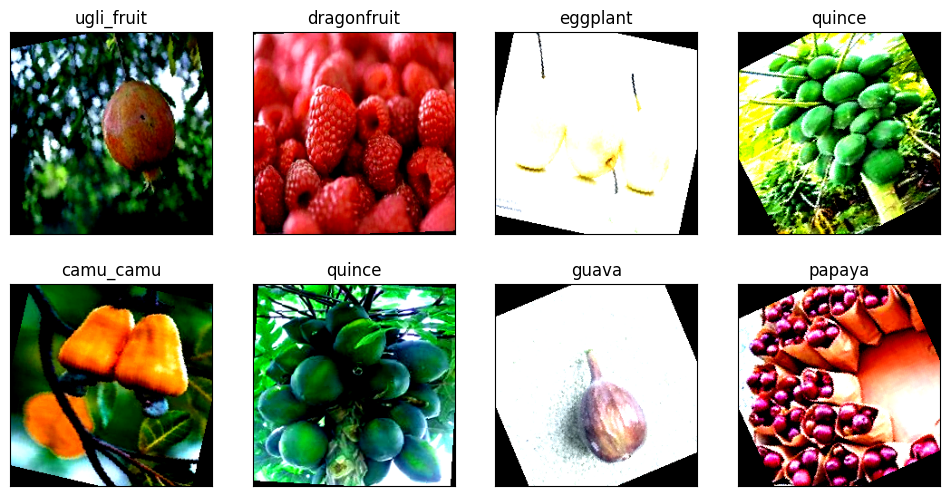

In [49]:
classes = train_data.classes

dataiter = iter(train_loader)

images, labels = next(dataiter)
images = images.numpy() # convert images to numpy for display

images, labels = next(dataiter)

fig = plt.figure(figsize=(12, 6))
for idx in range(8):
  ax = fig.add_subplot(2, 4, idx+1, xticks=[], yticks=[])
  imshow(images[idx])
  ax.set_title(classes[labels[idx]])

## The Model

In [50]:
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()

        num_blocks = 5
        num_params = 16
        # img_size = 224

        self.blocks = nn.ModuleList()

        for idx in range(num_blocks):
            if idx == 0:
                self.blocks.append(
                    nn.Conv2d(3, num_params, kernel_size=3, stride=1, padding=1)
                )
            else:
                num_params *= 2
                self.blocks.append(
                    nn.Conv2d(int(num_params / 2), num_params, kernel_size=3, stride=1, padding=1)
                )
            self.blocks.append(nn.BatchNorm2d(num_params))
            self.blocks.append(nn.ReLU())

            self.blocks.append(
                    nn.Conv2d(num_params, num_params, kernel_size=3, stride=1, padding=1)
            )
            self.blocks.append(nn.BatchNorm2d(num_params))
            self.blocks.append(nn.ReLU())
            if idx < num_blocks - 1:
                self.blocks.append(nn.MaxPool2d(2, 2))
            else:
                self.blocks.append(nn.AdaptiveAvgPool2d((2, 2)))


        self.fc1 = nn.Linear(num_params * 2 * 2, 1024)
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, len(classes))

        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        for block in self.blocks:
            x = block(x)

        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.fc3(x)

        return x





model = Net()
print(model)

if(train_on_gpu):
  model.cuda()


Net(
  (blocks): ModuleList(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    

## Introducing the optimizer, Learning rate adjuster, and scaler

In [51]:
import torch.optim as optim
from torch.amp import autocast, GradScaler
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.7)
scaler = GradScaler('cuda' if train_on_gpu else 'cpu')

## Calculate Accuracies

In [52]:
def calculate_accuracy(model, dataloader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


Net(
  (blocks): ModuleList(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    

## Early Stopping
stop model early if validation stops improving

In [53]:
class EarlyStopping:
    def __init__(self, patience=6, min_delta=0.0001):
        self.min_delta = min_delta
        self.patience = patience
        self.counter = 0
        self.min_val_loss = float('inf')

    def early_stopper(self, val_loss):
        if val_loss < self.min_val_loss:
            self.min_val_loss = val_loss
            self.counter = 0
        elif val_loss > (self.min_val_loss + self.min_delta):
            self.counter += 1
            if self.counter >= self.patience:
                return True
        return False
            

In [54]:
n_epochs = 80

valid_loss_min = np.inf

if not train_on_gpu:
    print('CUDA is not available.  Training on CPU ...')
else:
    print('CUDA is available!  Training on GPU ...')

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
learning_rates = []

ealry_stopper = EarlyStopping()

for epoch in range(1, n_epochs+1):
    train_loss = 0.0
    valid_loss = 0.0

    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        if train_on_gpu:
            data, target = data.cuda(), target.cuda()

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * data.size(0)
        
    scheduler.step()

    current_lr = scheduler.get_last_lr()[0]
    learning_rates.append(current_lr)
    print(f"Current LR: {current_lr:.6e}")
    train_acc = calculate_accuracy(model, train_loader, device)
    val_acc = calculate_accuracy(model, val_loader, device)
    train_accuracies.append(train_acc * 100)
    val_accuracies.append(val_acc * 100)
    print(f'Train Accuracy: {train_acc:.4f}, Val Accuracy: {val_acc:.4f}')


    model.eval()
    for batch_idx, (data, target) in enumerate(val_loader):
        if train_on_gpu:
            data, target = data.cuda(), target.cuda()

        output = model(data)
        loss = criterion(output, target)

        valid_loss += loss.item() * data.size(0)

    train_loss = train_loss / len(train_loader.dataset)
    valid_loss = valid_loss / len(val_loader.dataset)

    train_losses.append(train_loss)
    val_losses.append(valid_loss)

    if ealry_stopper.early_stopper(valid_loss):
        print("Stopping Early...")
        break

    print('Epoch: {} \tTraining Loss: {:.6f} \tValidation Loss: {:.6f}'.format(
        epoch, train_loss, valid_loss))

    if valid_loss < valid_loss_min:
        print('Validation loss decreased ({:.6f} --> {:.6f}).  Saving model ...'.format(
            valid_loss_min, valid_loss))
        torch.save(model.state_dict(), 'model.pt')
        valid_loss_min = valid_loss



CUDA is available!  Training on GPU ...
Current LR: 1.000000e-03
Train Accuracy: 0.0635, Val Accuracy: 0.0692
Epoch: 1 	Training Loss: 4.147471 	Validation Loss: 3.921757
Validation loss decreased (inf --> 3.921757).  Saving model ...
Current LR: 1.000000e-03
Train Accuracy: 0.0995, Val Accuracy: 0.1208
Epoch: 2 	Training Loss: 3.805103 	Validation Loss: 3.560824
Validation loss decreased (3.921757 --> 3.560824).  Saving model ...
Current LR: 1.000000e-03
Train Accuracy: 0.1406, Val Accuracy: 0.1440
Epoch: 3 	Training Loss: 3.596718 	Validation Loss: 3.392589
Validation loss decreased (3.560824 --> 3.392589).  Saving model ...
Current LR: 1.000000e-03
Train Accuracy: 0.1669, Val Accuracy: 0.1868
Epoch: 4 	Training Loss: 3.414249 	Validation Loss: 3.155786
Validation loss decreased (3.392589 --> 3.155786).  Saving model ...
Current LR: 1.000000e-03
Train Accuracy: 0.1692, Val Accuracy: 0.1772
Epoch: 5 	Training Loss: 3.274571 	Validation Loss: 3.228235
Current LR: 1.000000e-03
Train Acc

## Plots

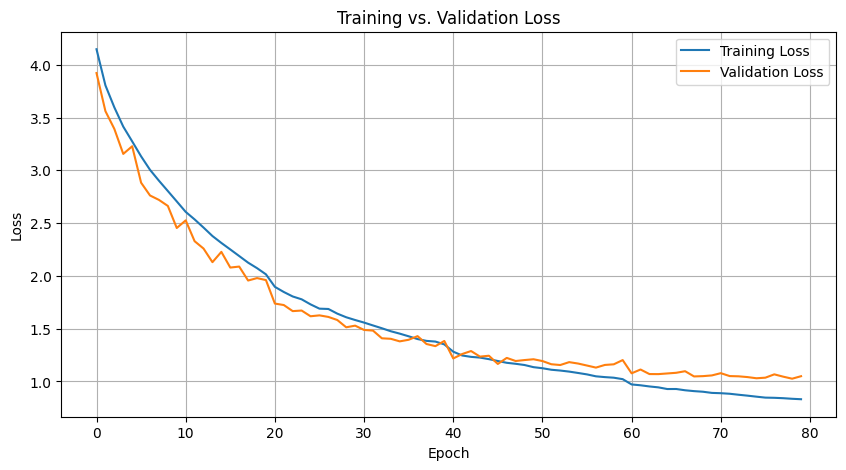

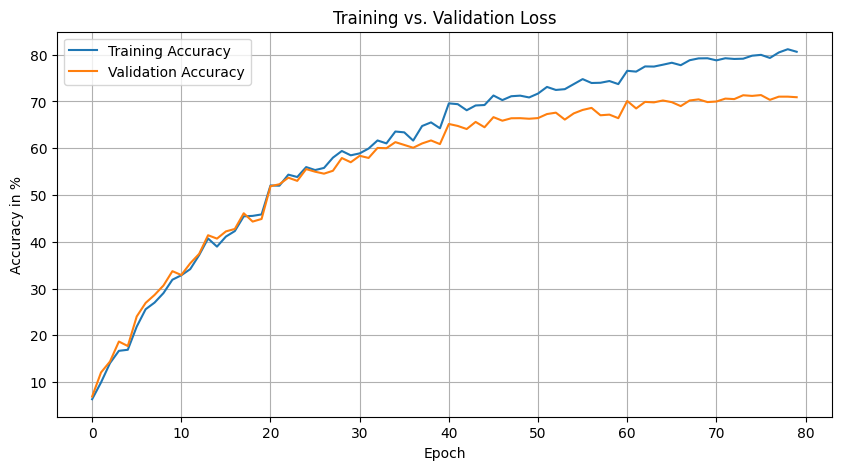

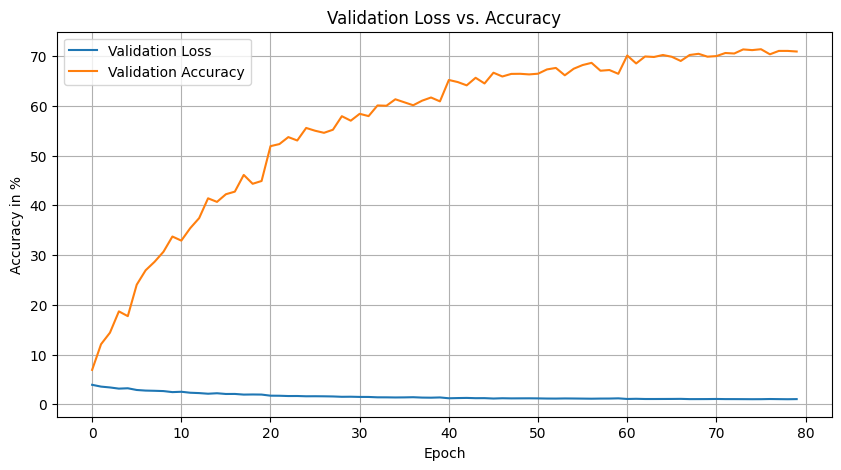

In [ ]:
# Loss Plot
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
# plt.plot(learning_rates, label='Learning Rate', linestyle='dashed')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs. Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# Accuracy Plot
plt.figure(figsize=(10, 5))
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy in %')
plt.title('Training vs. Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# Validation Accuracy vs Loss
# plt.figure(figsize=(10, 5))
# plt.plot(val_losses, label='Validation Loss')
# plt.plot(val_accuracies, label='Validation Accuracy')
# plt.xlabel('Epoch')
# plt.ylabel('Accuracy in %')
# plt.title('Validation Loss vs. Accuracy')
# plt.legend()
# plt.grid(True)
# plt.show()


In [56]:
model.load_state_dict(torch.load('model.pt'))


<All keys matched successfully>

## Testing the model

In [57]:
test_loss = 0.0
classes_correct = list(0. for i in range(100))
classes_total = list(0. for i in range(100))

model.eval()

classes = test_data.classes

for data, target in test_loader:
    if train_on_gpu:
        data, target = data.cuda(), target.cuda()

    output = model(data)
    loss = criterion(output, target)

    test_loss += loss.item() * data.size(0)

    _, pred = torch.max(output, 1)
    correct_tensor = pred.eq(target.data.view_as(pred))
    correct = np.squeeze(correct_tensor.cpu().numpy())

    for i in range(len(target)):
        label = target.data[i]
        classes_correct[label] += correct[i].item()
        classes_total[label] += 1

test_loss = test_loss / len(test_loader.dataset)
print('Test Loss: {:.6f}\n'.format(test_loss))

for i in range(100):
    if classes_total[i] > 0:
        print('Test Accuracy of %5s: %2d%% (%2d/%2d)' % (
            classes[i], 100 * classes_correct[i] / classes_total[i],
            np.sum(classes_correct[i]), np.sum(classes_total[i])))
    else:
        print('Test Accuracy of %5s: N/A (no training examples)' % (classes[i]))

print('\nTest Accuracy (Overall): %2d%% (%2d/%2d)' % (
    100. * np.sum(classes_correct) / np.sum(classes_total),
    np.sum(classes_correct), np.sum(classes_total)))

Test Loss: 1.044001

Test Accuracy of     0: 88% (44/50)
Test Accuracy of     1: 38% (19/50)
Test Accuracy of    10: 72% (36/50)
Test Accuracy of    11: 60% (30/50)
Test Accuracy of    12: 94% (47/50)
Test Accuracy of    13: 52% (26/50)
Test Accuracy of    14: 96% (48/50)
Test Accuracy of    15: 52% (26/50)
Test Accuracy of    16: 52% (26/50)
Test Accuracy of    17: 54% (27/50)
Test Accuracy of    18: 48% (24/50)
Test Accuracy of    19: 80% (40/50)
Test Accuracy of     2: 56% (28/50)
Test Accuracy of    20: 98% (49/50)
Test Accuracy of    21: 44% (22/50)
Test Accuracy of    22: 58% (29/50)
Test Accuracy of    23: 58% (29/50)
Test Accuracy of    24: 82% (41/50)
Test Accuracy of    25: 56% (28/50)
Test Accuracy of    26: 88% (44/50)
Test Accuracy of    27: 62% (31/50)
Test Accuracy of    28: 78% (39/50)
Test Accuracy of    29: 50% (25/50)
Test Accuracy of     3: 68% (34/50)
Test Accuracy of    30: 64% (32/50)
Test Accuracy of    31: 80% (40/50)
Test Accuracy of    32: 78% (39/50)
Test Ac

## Images of actual vs predicted

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.82].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5075778..1.8025708].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.40222222..1.7241396].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.82].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.8025708].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.82].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.82].
Clipping 

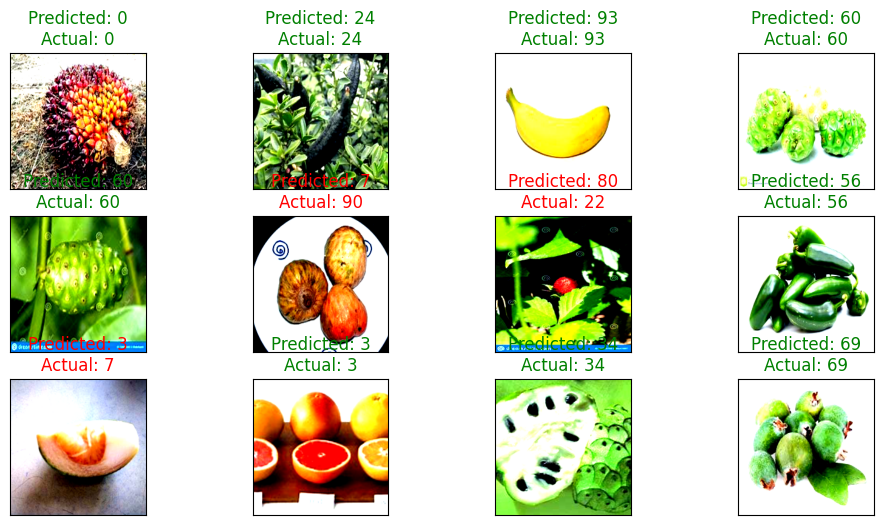

In [58]:
dataiter = iter(test_loader)
images, labels = next(dataiter)
# images = images.numpy()

if train_on_gpu:
    images = images.cuda()

output = model(images)
_, preds_tensor = torch.max(output, 1)
preds = preds_tensor.cpu().numpy()

fig = plt.figure(figsize=(12, 6))
for idx in np.arange(12):
    ax = fig.add_subplot(3, 4, idx+1, xticks=[], yticks=[])
    imshow(images[idx].cpu())
    ax.set_title(f'Predicted: {classes[preds[idx]]}\nActual: {classes[labels[idx]]}', color=('green' if preds[idx] == labels[idx] else 'red'))
    